# Data Job Market Analysis
### Turning raw job-market data into salary insights

**Author:** Deniz A. &nbsp;|&nbsp; **Tools:** Python, pandas, BeautifulSoup, matplotlib, seaborn

---

This notebook is an end-to-end **data analysis case study** on the market for
data professionals. It walks through the full analytical workflow the way I would
approach a real client question:

> **collect → clean → explore → visualize → conclude**

The goal is not just to produce charts, but to *think out loud* — at every step I
explain **what** I am doing and **why**, then state the **finding** before moving on.

> **A note on the data (full transparency).**
> This project uses **two data layers**:
> 1. A small **live web-scraping demo** against a public sandbox site that exists
>    specifically for scraping practice — this demonstrates data-collection skill
>    ethically and legally.
> 2. A **synthetic salary dataset** that mirrors the schema of the well-known
>    Kaggle *"Data Science Job Salaries"* dataset. It is generated from documented,
>    realistic assumptions (seniority premium, geographic differences, a remote
>    premium, year-over-year growth). I use synthetic data so the repository is
>    fully self-contained and free of licensing concerns. **This is stated openly
>    here, in the README, and in the Data Collection section — the analytical
>    workflow is the point, and it transfers directly to the real dataset.**


## 1. Introduction & Objectives

The market for data roles has grown quickly and is notoriously opaque about pay.
A candidate weighing an offer, or a company setting a compensation band, needs
clear answers to a few practical questions. This analysis sets out to answer them.

**Business questions**

1. **Which job titles are most in demand, and which pay the most?**
2. **How strongly does experience level drive salary?**
3. **Does remote work carry a salary premium?**
4. **How do salaries differ by country / location?**
5. **What is the salary trend over recent years?**
6. **Does company size affect pay?**

**Why this matters.** Answers to these questions help a *candidate* benchmark an
offer and target the highest-leverage roles, and help an *employer* set
competitive, data-driven compensation bands instead of guessing.

By the end we will have a cleaned dataset, a set of focused visualizations, and a
short list of plain-English, decision-ready insights.


### Setup

A small amount of configuration up front keeps the rest of the notebook clean:
project paths that work whether the notebook is run from the repo root or from
`notebooks/`, and a consistent, professional visual style anchored on a single
blue palette so every chart looks like it belongs to the same report.

In [1]:
%matplotlib inline
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Resolve project paths robustly: the notebook may be executed from the repo
# root (interactive Jupyter) or from the notebooks/ folder (nbconvert).
CWD = Path.cwd()
PROJECT_ROOT = CWD if (CWD / "data").exists() else CWD.parent
DATA_RAW = PROJECT_ROOT / "data" / "raw"
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
ASSETS = PROJECT_ROOT / "assets"
for _p in (DATA_RAW, DATA_PROCESSED, ASSETS):
    _p.mkdir(parents=True, exist_ok=True)

# Make the local source modules (scraper.py, generate_data.py) importable.
sys.path.insert(0, str(PROJECT_ROOT / "src"))

# ---- Consistent visual identity (blue-led, analytical, not decorative) ----
PRIMARY = "#2563eb"       # main blue
PRIMARY_DARK = "#1e3a8a"  # darker blue for the second series
ACCENT = "#f59e0b"        # amber, used sparingly to highlight one thing
GREY = "#64748b"
BLUE_SEQ = ["#dbeafe", "#bfdbfe", "#93c5fd", "#60a5fa",
            "#3b82f6", "#2563eb", "#1d4ed8", "#1e40af"]

sns.set_theme(style="whitegrid")
plt.rcParams.update({
    "figure.dpi": 110,
    "savefig.dpi": 150,
    "savefig.bbox": "tight",
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
    "axes.labelsize": 11,
    "axes.edgecolor": "#cbd5e1",
    "grid.color": "#e2e8f0",
})
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)


def usd(x, _=None):
    "Format a number as a compact USD string, e.g. 142000 -> '$142k'."
    return f"${x/1000:,.0f}k"


def save_fig(fig, name):
    "Save a figure into assets/ (for embedding in the README) and return its path."
    path = ASSETS / name
    fig.savefig(path)
    return path


# Human-readable names for the ISO country codes used in the dataset.
COUNTRY_NAMES = {
    "US": "United States", "GB": "United Kingdom", "CA": "Canada", "IN": "India",
    "DE": "Germany", "FR": "France", "ES": "Spain", "AU": "Australia",
    "NL": "Netherlands", "BR": "Brazil", "PT": "Portugal", "PL": "Poland",
    "JP": "Japan", "CH": "Switzerland", "SG": "Singapore",
}

print(f"Project root : {PROJECT_ROOT}")
print(f"pandas {pd.__version__} | numpy {np.__version__} | seaborn {sns.__version__}")

Project root : E:\Proje\UPWORK\data-job-market-analysis
pandas 3.0.2 | numpy 2.4.2 | seaborn 0.13.2


## 2. Data Collection

This project collects data in **two layers**, each chosen deliberately.

### 2.1 Ethical web-scraping demo

First, a self-contained demonstration of **web scraping** — a core data-collection
skill. Scraping live commercial job boards is legally and ethically fraught (most
forbid automated access in their Terms of Service). So instead I scrape
[`realpython.github.io/fake-jobs`](https://realpython.github.io/fake-jobs/), a
sandbox site **built specifically so people can practice scraping legally**. It
contains fabricated postings and is meant to be scraped, so the exercise is safe
and ToS-friendly.

The logic lives in [`src/scraper.py`](../src/scraper.py) and follows respectful
scraping practices:

- an **honest, descriptive `User-Agent`** (we identify ourselves rather than
  impersonate a browser),
- a **polite delay** between requests so we never hammer the server,
- **timeouts and explicit error handling** so we fail gracefully,
- we collect **only the fields we need** (title, company, location, date).


In [2]:
from scraper import scrape_jobs, save_raw, BASE_URL

# Try a live scrape; if the machine is offline, fall back to the saved snapshot
# so the notebook always runs end-to-end and reproduces the same output.
try:
    jobs_df = scrape_jobs(BASE_URL)
    save_raw(jobs_df, DATA_RAW / "scraped_jobs.csv")
    source = "live scrape"
except Exception as exc:
    print(f"Live scrape unavailable ({exc}). Loading saved snapshot instead.")
    jobs_df = pd.read_csv(DATA_RAW / "scraped_jobs.csv", parse_dates=["date_posted"])
    source = "saved snapshot"

print(f"Collected {len(jobs_df)} job postings via {source}.")
print(f"Unique companies: {jobs_df['company'].nunique()} | "
      f"Unique locations: {jobs_df['location'].nunique()}")
jobs_df.head()

Collected 100 job postings via live scrape.
Unique companies: 99 | Unique locations: 100


,title,company,location,date_posted,apply_url
0,Senior Python Developer,"Payne, Roberts and Davis","Stewartbury, AA",2021-04-08,https://realpython.github.io/fake-jobs/jobs/se...
1,Energy engineer,Vasquez-Davidson,"Christopherville, AA",2021-04-08,https://realpython.github.io/fake-jobs/jobs/en...
2,Legal executive,"Jackson, Chambers and Levy","Port Ericaburgh, AA",2021-04-08,https://realpython.github.io/fake-jobs/jobs/le...
3,Fitness centre manager,Savage-Bradley,"East Seanview, AP",2021-04-08,https://realpython.github.io/fake-jobs/jobs/fi...
4,Product manager,Ramirez Inc,"North Jamieview, AP",2021-04-08,https://realpython.github.io/fake-jobs/jobs/pr...


The scraper cleanly returns **100 structured postings** from unstructured HTML —
that is the skill being demonstrated. The sandbox postings are generic (not data
roles) and carry no salary information, so they are not the basis of the salary
analysis. For that we turn to a purpose-built salary dataset.

### 2.2 The salary dataset (synthetic, realistic)

The core analysis uses a dataset with the **same schema as Kaggle's
*"Data Science Job Salaries"*** dataset:

| Column | Meaning |
|---|---|
| `work_year` | Year the salary was recorded |
| `experience_level` | EN / MI / SE / EX (entry → executive) |
| `employment_type` | FT / PT / CT / FL |
| `job_title` | Role title |
| `salary_in_usd` | Annual gross salary in USD |
| `employee_residence` | Employee country (ISO code) |
| `remote_ratio` | 0 = onsite, 50 = hybrid, 100 = remote |
| `company_location` | Company country (ISO code) |
| `company_size` | S / M / L |

As stated up front, this dataset is **synthetic** — generated by
[`src/generate_data.py`](../src/generate_data.py) from documented, realistic
assumptions, and deliberately seeded so the numbers are identical on every run.
It also contains a **small amount of intentional "dirt"** (duplicates, missing
values, a few data-entry outliers) so that the cleaning step below is genuine.

In [3]:
RAW_SALARY_PATH = DATA_RAW / "data_jobs_salaries_raw.csv"

# Generate the raw dataset on first run if it is not already present.
if not RAW_SALARY_PATH.exists():
    import generate_data
    generate_data.generate(RAW_SALARY_PATH)

raw = pd.read_csv(RAW_SALARY_PATH)
print(f"Raw salary dataset: {raw.shape[0]:,} rows x {raw.shape[1]} columns")
raw.head()

Raw salary dataset: 9,080 rows x 9 columns


,work_year,experience_level,employment_type,job_title,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2023,EX,FT,Analytics Engineer,253600.0,US,100.0,US,M
1,2022,SE,FT,Data Scientist,259100.0,DE,50.0,US,M
2,2020,SE,FT,Research Scientist,125200.0,GB,0.0,GB,L
3,2024,EX,FT,Analytics Engineer,230000.0,NL,0.0,NL,L
4,2021,SE,FT,Data Analyst,NaN,US,0.0,US,M


## 3. Data Cleaning & Preparation

Real datasets are never analysis-ready, and this one is no exception. Before
trusting any number, I inspect the data and fix what is wrong — explaining the
reasoning behind each decision, because *how* you clean data quietly determines
every conclusion that follows.

Let's start by looking at the raw data honestly.

In [4]:
raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 9080 entries, 0 to 9079
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   work_year           9080 non-null   int64  
 1   experience_level    9080 non-null   str    
 2   employment_type     9080 non-null   str    
 3   job_title           9080 non-null   str    
 4   salary_in_usd       9035 non-null   float64
 5   employee_residence  9080 non-null   str    
 6   remote_ratio        8940 non-null   float64
 7   company_location    9080 non-null   str    
 8   company_size        8900 non-null   str    
dtypes: float64(2), int64(1), str(6)
memory usage: 868.6 KB


In [5]:
print("Missing values per column:")
print(raw.isna().sum())
print(f"\nExact duplicate rows: {raw.duplicated().sum()}")
print("\nNumeric summary (note the salary min/max):")
raw.select_dtypes("number").describe().round(0)

Missing values per column:
work_year               0
experience_level        0
employment_type         0
job_title               0
salary_in_usd          45
employee_residence      0
remote_ratio          140
company_location        0
company_size          180
dtype: int64

Exact duplicate rows: 94

Numeric summary (note the salary min/max):


,work_year,salary_in_usd,remote_ratio
count,9080.0,9035.0,8940.0
mean,2023.0,151397.0,46.0
std,1.0,80036.0,45.0
min,2020.0,8.0,0.0
25%,2022.0,98500.0,0.0
50%,2023.0,142000.0,50.0
75%,2024.0,192800.0,100.0
max,2024.0,2276000.0,100.0


The inspection surfaces four concrete problems:

1. **Duplicate rows** — a classic export artefact that would double-count records.
2. **Missing values** in `salary_in_usd`, `remote_ratio` and `company_size`.
3. **Impossible salary values** — the `min` and `max` are far outside any real
   salary, a tell-tale sign of data-entry errors (an extra zero, or a figure typed
   in thousands).
4. **Inconsistent text** in `job_title` (stray whitespace and casing), which would
   fragment the same role into several "different" titles.

We fix them one at a time.

**Step 1 — Remove duplicate rows.** Duplicates inflate sample sizes and bias
any average toward the repeated records, so they go first.

In [6]:
df = raw.copy()
before = len(df)
df = df.drop_duplicates().reset_index(drop=True)
print(f"Removed {before - len(df)} duplicate rows -> {len(df):,} rows remain.")

Removed 94 duplicate rows -> 8,986 rows remain.


**Step 2 — Standardize `job_title` text.** The same role appears as
`"Data Analyst"`, `"data analyst"`, and `"Data Analyst  "` (trailing spaces).
Left alone, these would be treated as three different jobs. I trim whitespace,
collapse internal spaces, and snap each title back to a known canonical name so
casing like *AI* is preserved correctly (a naive title-case would produce
"Ai Engineer").

In [7]:
CANONICAL_TITLES = {t.lower(): t for t in [
    "Data Analyst", "Data Scientist", "Data Engineer", "Machine Learning Engineer",
    "Analytics Engineer", "Business Intelligence Analyst", "Research Scientist",
    "AI Engineer", "Data Architect", "Data Science Manager",
]}

print("Distinct job_title values BEFORE:", df["job_title"].nunique())
df["job_title"] = (
    df["job_title"].str.strip()
    .str.replace(r"\s+", " ", regex=True)
    .str.lower()
    .map(CANONICAL_TITLES)
)
print("Distinct job_title values AFTER :", df["job_title"].nunique())

Distinct job_title values BEFORE: 29
Distinct job_title values AFTER : 10


**Step 3 — Handle missing values.** The strategy depends on the column:

- `salary_in_usd` is the **target** of the whole analysis — a row without it
  cannot inform any salary question, and imputing the very thing we are studying
  would manufacture conclusions. Those rows are dropped.
- `remote_ratio` and `company_size` are **group keys** used for comparisons.
  Imputing them (e.g. with the mode) would quietly bias exactly the group
  comparisons we care about. Since they are missing in **under 2%** of rows, I use
  **complete-case analysis** and drop the affected rows — a transparent trade-off:
  we lose a sliver of data to avoid biasing the results.

In [8]:
missing_before = int(df[["salary_in_usd", "remote_ratio", "company_size"]].isna().any(axis=1).sum())
df = df.dropna(subset=["salary_in_usd", "remote_ratio", "company_size"]).reset_index(drop=True)
print(f"Dropped {missing_before} rows with a missing critical field.")
print(f"Rows remaining: {len(df):,}")

Dropped 359 rows with a missing critical field.
Rows remaining: 8,627


**Step 4 — Detect and remove impossible salaries.** A boxplot-style look at
the extremes shows values that cannot be real annual salaries. Rather than blindly
trimming by a statistical rule (which could discard legitimate high executive
pay), I apply a **domain rule**: realistic annual salaries for data roles sit
comfortably within **\$10,000–\$800,000**. Anything outside that band is a
data-entry error and is removed. I report exactly how many rows this affects so
the decision is auditable.

In [9]:
print("Salary BEFORE outlier removal:")
print(df["salary_in_usd"].describe().round(0))

LOW, HIGH = 10_000, 800_000
mask = df["salary_in_usd"].between(LOW, HIGH)
print(f"\nRemoving {int((~mask).sum())} impossible salary values "
      f"({(~mask).mean() * 100:.2f}% of rows).")

df = df[mask].reset_index(drop=True)
print("\nSalary AFTER outlier removal:")
print(df["salary_in_usd"].describe().round(0))

Salary BEFORE outlier removal:
count       8627.0
mean      151573.0
std        80575.0
min            8.0
25%        98500.0
50%       142000.0
75%       192900.0
max      2276000.0
Name: salary_in_usd, dtype: float64

Removing 12 impossible salary values (0.14% of rows).

Salary AFTER outlier removal:
count      8615.0
mean     150789.0
std       70117.0
min       18600.0
25%       98600.0
50%      142000.0
75%      192800.0
max      678000.0
Name: salary_in_usd, dtype: float64


**Step 5 — Convert types and decode categories.** Finally, I turn the
machine-friendly codes into human-readable, **ordered** categories. Ordering
matters: it makes *Entry-level → Mid → Senior → Executive* sort correctly in every
table and chart automatically, instead of alphabetically. I also derive a tidy
`remote_type` label from `remote_ratio`.

In [10]:
df["salary_in_usd"] = df["salary_in_usd"].astype(int)
df["remote_ratio"] = df["remote_ratio"].astype(int)

exp_map = {"EN": "Entry-level", "MI": "Mid-level", "SE": "Senior", "EX": "Executive"}
emp_map = {"FT": "Full-time", "PT": "Part-time", "CT": "Contract", "FL": "Freelance"}
size_map = {"S": "Small", "M": "Medium", "L": "Large"}
remote_map = {0: "Onsite", 50: "Hybrid", 100: "Remote"}

exp_order = ["Entry-level", "Mid-level", "Senior", "Executive"]
size_order = ["Small", "Medium", "Large"]
remote_order = ["Onsite", "Hybrid", "Remote"]

df["experience_level"] = pd.Categorical(
    df["experience_level"].map(exp_map), categories=exp_order, ordered=True)
df["company_size"] = pd.Categorical(
    df["company_size"].map(size_map), categories=size_order, ordered=True)
df["remote_type"] = pd.Categorical(
    df["remote_ratio"].map(remote_map), categories=remote_order, ordered=True)
df["employment_type"] = df["employment_type"].map(emp_map).astype("category")

df.info()
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 8615 entries, 0 to 8614
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype   
---  ------              --------------  -----   
 0   work_year           8615 non-null   int64   
 1   experience_level    8615 non-null   category
 2   employment_type     8615 non-null   category
 3   job_title           8615 non-null   str     
 4   salary_in_usd       8615 non-null   int64   
 5   employee_residence  8615 non-null   str     
 6   remote_ratio        8615 non-null   int64   
 7   company_location    8615 non-null   str     
 8   company_size        8615 non-null   category
 9   remote_type         8615 non-null   category
dtypes: category(4), int64(3), str(3)
memory usage: 616.6 KB


,work_year,experience_level,employment_type,job_title,salary_in_usd,employee_residence,remote_ratio,company_location,company_size,remote_type
0,2023,Executive,Full-time,Analytics Engineer,253600,US,100,US,Medium,Remote
1,2022,Senior,Full-time,Data Scientist,259100,DE,50,US,Medium,Hybrid
2,2020,Senior,Full-time,Research Scientist,125200,GB,0,GB,Large,Onsite
3,2024,Executive,Full-time,Analytics Engineer,230000,NL,0,NL,Large,Onsite
4,2023,Entry-level,Contract,Analytics Engineer,100300,CA,0,CA,Large,Onsite


**Save the cleaned dataset.** The analysis-ready data is written to
`data/processed/` so the cleaning never has to be repeated and the exploration
below starts from a trustworthy base.

In [11]:
CLEAN_PATH = DATA_PROCESSED / "data_jobs_salaries_clean.csv"
df.to_csv(CLEAN_PATH, index=False)

print(f"Raw rows     : {len(raw):,}")
print(f"Clean rows   : {len(df):,}  ({len(raw) - len(df):,} removed in cleaning)")
print(f"Saved to     : {CLEAN_PATH}")

Raw rows     : 9,080
Clean rows   : 8,615  (465 removed in cleaning)
Saved to     : E:\Proje\UPWORK\data-job-market-analysis\data\processed\data_jobs_salaries_clean.csv


## 4. Exploratory Data Analysis

With clean data in hand, I work through the six business questions. In this section
I focus on the **numbers** — the aggregations that actually answer each question —
and state the finding. The next section turns the headline results into polished
visuals. (Each aggregation is stored in a variable here and reused for plotting,
so nothing is computed twice.)

First, a quick look at the salary distribution to understand the variable
everything else depends on.

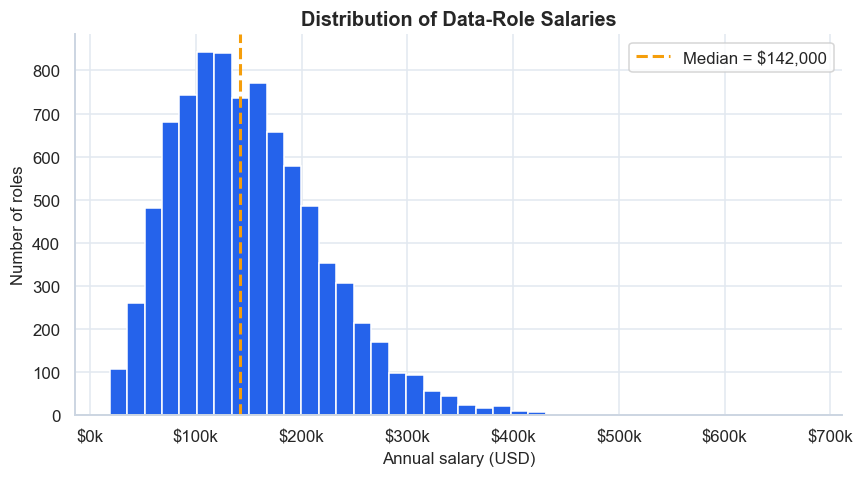

count      8615.0
mean     150789.0
std       70117.0
min       18600.0
25%       98600.0
50%      142000.0
75%      192800.0
max      678000.0
Name: salary_in_usd, dtype: float64


In [12]:
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.hist(df["salary_in_usd"], bins=40, color=PRIMARY, edgecolor="white")
median_salary = df["salary_in_usd"].median()
ax.axvline(median_salary, color=ACCENT, lw=2, ls="--",
           label=f"Median = ${median_salary:,.0f}")
ax.set_title("Distribution of Data-Role Salaries")
ax.set_xlabel("Annual salary (USD)")
ax.set_ylabel("Number of roles")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(usd))
ax.legend()
sns.despine(fig)
save_fig(fig, "salary_distribution.png")
plt.show()

print(df["salary_in_usd"].describe().round(0))

The distribution is **right-skewed** — most roles cluster in a broad middle
band while a thinner tail of senior/executive roles reaches much higher. Because
of that skew I report the **median** (not the mean) throughout, as it better
represents the "typical" salary.

### Q1 — Which titles are most in demand, and which pay the most?

"In demand" = how often a title appears in the data; "pays the most" = its median
salary. Looking at both together separates the *common* roles from the *lucrative*
ones.

In [13]:
title_stats = (
    df.groupby("job_title", observed=True)
      .agg(postings=("salary_in_usd", "size"),
           median_salary=("salary_in_usd", "median"))
      .sort_values("postings", ascending=False)
)
title_stats.round(0)

,postings,median_salary
job_title,,
Data Engineer,1579,146700.0
Data Scientist,1519,150500.0
Data Analyst,1383,109600.0
Machine Learning Engineer,1048,168600.0
Business Intelligence Analyst,778,114600.0
Analytics Engineer,701,145700.0
Research Scientist,499,152900.0
AI Engineer,434,178000.0
Data Architect,338,164600.0


**Finding.** *Data Engineer*, *Data Scientist* and *Data Analyst* dominate by
**volume** — they are the backbone of the market. But the **best-paid** titles are
the specialist/leadership roles: *Data Science Manager* (~\$188k median),
*AI Engineer* (~\$178k) and *Machine Learning Engineer* (~\$169k). The Data Analyst
role is the third most common yet pays the **least** (~\$110k) — a key signal for
anyone planning a career path: the common entry point is not where the money is.

### Q2 — How strongly does experience level drive salary?

In [14]:
exp_stats = (
    df.groupby("experience_level", observed=True)["salary_in_usd"]
      .agg(count="count", median="median", mean="mean")
      .round(0)
)
exp_stats

,count,median,mean
experience_level,,,
Entry-level,1711,86000.0,86670.0
Mid-level,2733,131900.0,132778.0
Senior,3459,177800.0,178954.0
Executive,712,236050.0,237178.0


**Finding.** Experience is the **single strongest driver** of pay. Each step up
the ladder brings a large jump — from a median of **~\$86k** at entry-level to
**~\$236k** at executive, about a **2.7×** difference. Seniority, not job title, is
where the biggest money lever sits.

### Q3 — Does remote work carry a salary premium?

In [15]:
remote_stats = (
    df.groupby("remote_type", observed=True)["salary_in_usd"]
      .agg(count="count", median="median", mean="mean")
      .round(0)
)
remote_stats

,count,median,mean
remote_type,,,
Onsite,3759,138800.0,147901.0
Hybrid,1723,142900.0,151752.0
Remote,3133,145400.0,153724.0


**Finding.** There is a **modest** remote premium: fully-remote roles pay about
**5% more** than onsite ones at the median (~\$145k vs ~\$139k), with hybrid in
between. Remote work is *not* a major pay lever compared with experience or
location — useful context for anyone tempted to over-weight it when comparing
offers.

### Q4 — How do salaries differ by country?

I group by **company location** (where the role is actually paid) and keep only
countries with at least 30 roles, so a single outlier cannot masquerade as a
"high-paying country".

In [16]:
country_stats = (
    df.groupby("company_location", observed=True)
      .agg(roles=("salary_in_usd", "size"),
           median_salary=("salary_in_usd", "median"))
)
country_stats = (
    country_stats[country_stats["roles"] >= 30]
    .sort_values("median_salary", ascending=False)
)
country_stats.assign(country=country_stats.index.map(COUNTRY_NAMES)).round(0)

,roles,median_salary,country
company_location,,,
US,4920,167600.0,United States
CH,129,161700.0,Switzerland
CA,506,150400.0,Canada
SG,88,138850.0,Singapore
AU,182,126600.0,Australia
GB,636,125650.0,United Kingdom
NL,195,121300.0,Netherlands
DE,445,121100.0,Germany
FR,257,108200.0,France


**Finding.** Location is the **second-biggest driver** after experience. The
**United States** (~\$168k median) and **Switzerland** (~\$162k) lead by a wide
margin, followed by other Western markets (Canada, the UK, Australia). Emerging
markets such as **India** (~\$60k) and **Brazil** (~\$55k) sit far lower — the same
role can pay **~3× more** depending on where the company is based, which is exactly
why remote-friendly, US-based roles are so sought after.

### Q5 — What is the salary trend over recent years?

In [17]:
year_stats = df.groupby("work_year", observed=True)["salary_in_usd"].median()
year_by_exp = (
    df.groupby(["work_year", "experience_level"], observed=True)["salary_in_usd"]
      .median()
      .unstack()
)
growth = (year_stats.iloc[-1] / year_stats.iloc[0] - 1) * 100
print(f"Median salary {year_stats.index[0]}: ${year_stats.iloc[0]:,.0f}")
print(f"Median salary {year_stats.index[-1]}: ${year_stats.iloc[-1]:,.0f}")
print(f"Cumulative growth: {growth:.1f}%")
year_by_exp.round(0)

Median salary 2020: $122,300
Median salary 2024: $151,100
Cumulative growth: 23.5%


experience_level,Entry-level,Mid-level,Senior,Executive
work_year,,,,
2020,72900.0,114500.0,151700.0,217150.0
2021,80450.0,120400.0,159500.0,212450.0
2022,86850.0,128950.0,177200.0,218650.0
2023,84550.0,134000.0,180100.0,245100.0
2024,92200.0,141600.0,188700.0,248300.0


**Finding.** Salaries have risen **steadily year over year** — the overall median
climbed from **~\$122k in 2020 to ~\$151k in 2024 (+23.5%)** — with growth visible
at *every* experience level. Pay for data roles has trended firmly upward, a
tailwind for candidates and a budgeting reality for employers.

### Q6 — Does company size affect pay?

In [18]:
size_stats = (
    df.groupby("company_size", observed=True)["salary_in_usd"]
      .agg(count="count", median="median")
      .round(0)
)
size_stats

,count,median
company_size,,
Small,1248,126300.0
Medium,4800,141400.0
Large,2567,153000.0


**Finding.** Larger companies pay **more** at the median (~\$153k) than small ones
(~\$126k), with medium-sized firms in between (~\$141k). The effect is real but
**smaller** than experience or location — company size nudges pay rather than
defining it.

## 5. Visualizations

Each chart below answers one business question and is built from the aggregations
computed above (no recomputation). The style is deliberately **analytical, not
decorative** — a consistent blue palette, value labels where they aid reading, and
no chart-junk. These figures are also saved to `assets/` for the README.

**Demand vs. pay by role.** The clearest way to see the gap between *how
common* a role is and *how well it pays* is to put the two side by side.

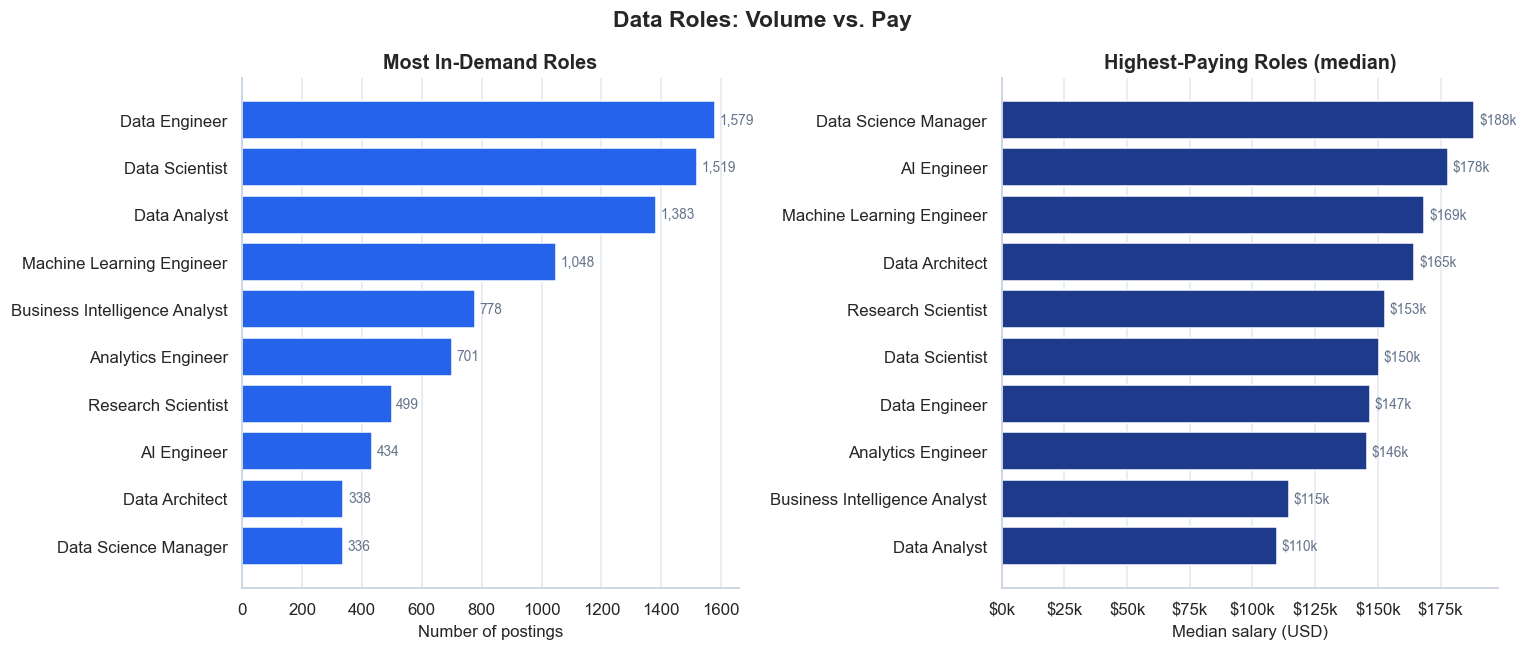

In [19]:
ts_demand = title_stats.sort_values("postings")
ts_pay = title_stats.sort_values("median_salary")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].barh(ts_demand.index, ts_demand["postings"], color=PRIMARY)
axes[0].set_title("Most In-Demand Roles")
axes[0].set_xlabel("Number of postings")
for y, v in enumerate(ts_demand["postings"]):
    axes[0].text(v + max(ts_demand["postings"]) * 0.01, y, f"{int(v):,}",
                 va="center", fontsize=9, color=GREY)

axes[1].barh(ts_pay.index, ts_pay["median_salary"], color=PRIMARY_DARK)
axes[1].set_title("Highest-Paying Roles (median)")
axes[1].set_xlabel("Median salary (USD)")
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(usd))
for y, v in enumerate(ts_pay["median_salary"]):
    axes[1].text(v + max(ts_pay["median_salary"]) * 0.01, y, f"${v/1000:.0f}k",
                 va="center", fontsize=9, color=GREY)

for ax in axes:
    ax.grid(axis="x", color="#e2e8f0")
    ax.grid(axis="y", visible=False)
fig.suptitle("Data Roles: Volume vs. Pay", fontsize=15, fontweight="bold")
sns.despine(fig)
fig.tight_layout()
save_fig(fig, "salary_by_title.png")
plt.show()

**The seniority ladder.** Median salary rises sharply with each experience
level — the steepest gradient in the whole dataset.

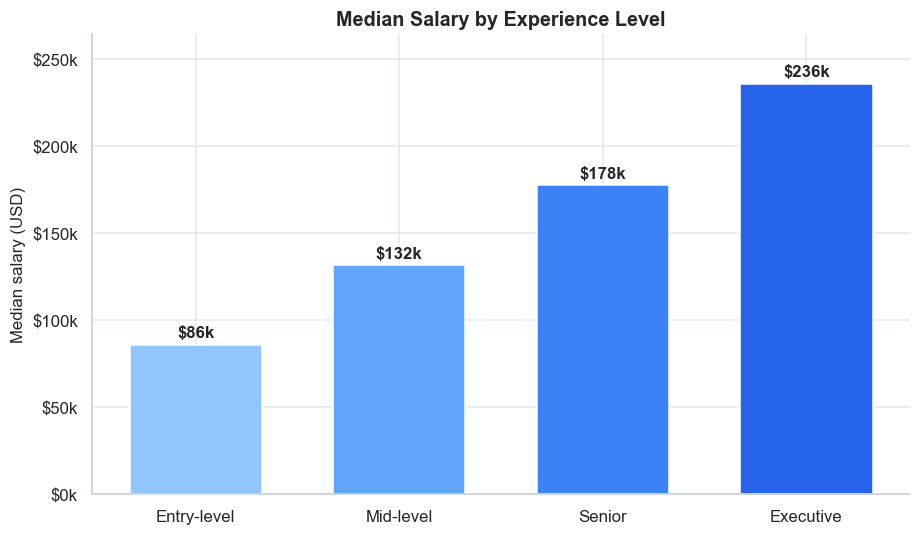

In [20]:
fig, ax = plt.subplots(figsize=(8.5, 5))
vals = exp_stats["median"]
bars = ax.bar(vals.index.astype(str), vals.values, color=BLUE_SEQ[2:6], width=0.65)
ax.set_title("Median Salary by Experience Level")
ax.set_ylabel("Median salary (USD)")
ax.set_xlabel("")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(usd))
for b, v in zip(bars, vals.values):
    ax.text(b.get_x() + b.get_width() / 2, v + max(vals) * 0.01,
            f"${v/1000:.0f}k", ha="center", va="bottom", fontweight="bold")
ax.margins(y=0.12)
sns.despine(fig)
fig.tight_layout()
save_fig(fig, "salary_by_experience.png")
plt.show()

**The remote premium is modest.** Plotted on a zero-based axis, the
onsite → hybrid → remote steps are real but small — visual proof that remote work
is not a salary game-changer.

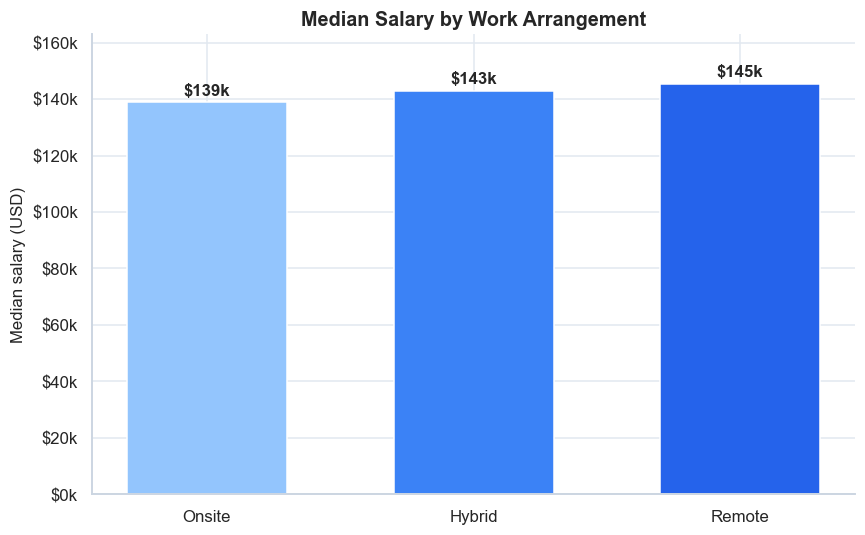

In [21]:
fig, ax = plt.subplots(figsize=(8, 5))
vals = remote_stats["median"]
colors = [BLUE_SEQ[2], BLUE_SEQ[4], PRIMARY]
bars = ax.bar(vals.index.astype(str), vals.values, color=colors, width=0.6)
ax.set_title("Median Salary by Work Arrangement")
ax.set_ylabel("Median salary (USD)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(usd))
for b, v in zip(bars, vals.values):
    ax.text(b.get_x() + b.get_width() / 2, v + max(vals) * 0.01,
            f"${v/1000:.0f}k", ha="center", va="bottom", fontweight="bold")
ax.margins(y=0.12)
sns.despine(fig)
fig.tight_layout()
save_fig(fig, "salary_by_remote.png")
plt.show()

**Geography sets the ceiling.** Median pay by company location (≥30 roles)
shows how far the US and Switzerland sit above emerging markets.

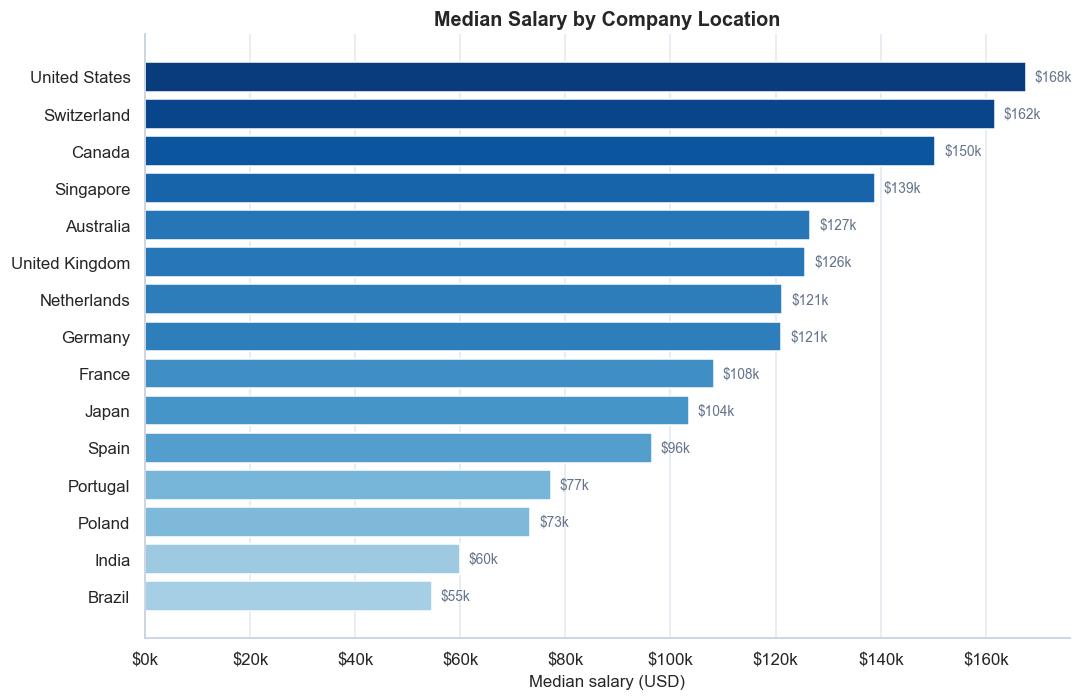

In [22]:
cs = country_stats.sort_values("median_salary").copy()
labels = [COUNTRY_NAMES.get(c, c) for c in cs.index]
norm = (cs["median_salary"] - cs["median_salary"].min()) / (
    cs["median_salary"].max() - cs["median_salary"].min())
colors = plt.cm.Blues(0.35 + 0.6 * norm.values)

fig, ax = plt.subplots(figsize=(10, 6.5))
ax.barh(labels, cs["median_salary"], color=colors)
ax.set_title("Median Salary by Company Location")
ax.set_xlabel("Median salary (USD)")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(usd))
for y, v in enumerate(cs["median_salary"]):
    ax.text(v + cs["median_salary"].max() * 0.01, y, f"${v/1000:.0f}k",
            va="center", fontsize=9, color=GREY)
ax.grid(axis="x", color="#e2e8f0")
ax.grid(axis="y", visible=False)
sns.despine(fig)
fig.tight_layout()
save_fig(fig, "salary_by_country.png")
plt.show()

**A steady upward trend.** Median salary by year, broken out by experience
level — the climb is visible across the board, not just at the top.

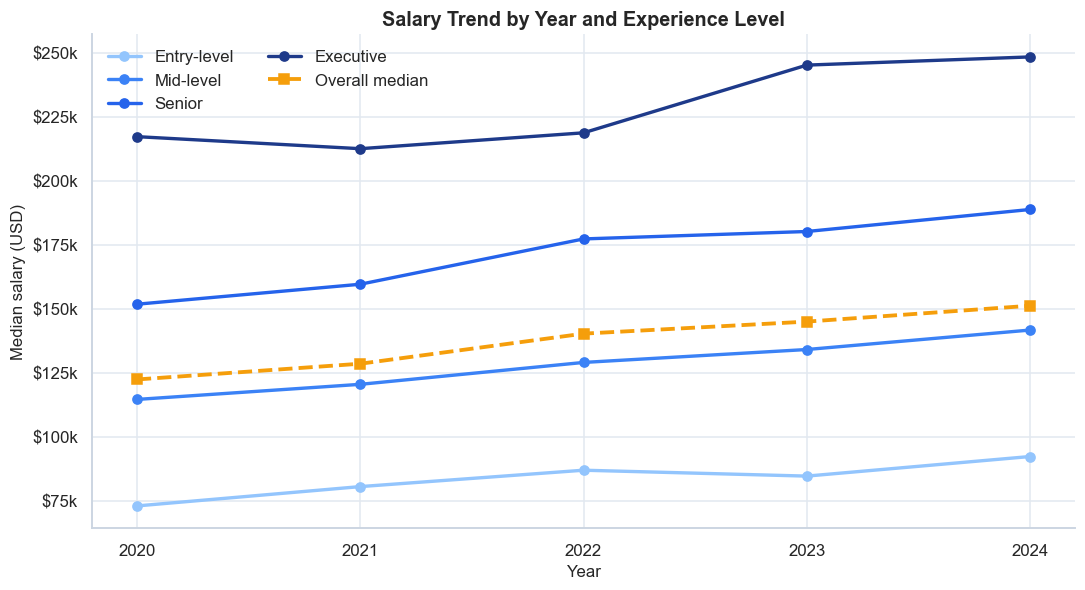

In [23]:
fig, ax = plt.subplots(figsize=(10, 5.5))
level_colors = {"Entry-level": BLUE_SEQ[2], "Mid-level": BLUE_SEQ[4],
                "Senior": PRIMARY, "Executive": PRIMARY_DARK}
for level in ["Entry-level", "Mid-level", "Senior", "Executive"]:
    if level in year_by_exp.columns:
        ax.plot(year_by_exp.index, year_by_exp[level], marker="o", lw=2.2,
                color=level_colors[level], label=level)
ax.plot(year_stats.index, year_stats.values, marker="s", lw=2.5, ls="--",
        color=ACCENT, label="Overall median")
ax.set_title("Salary Trend by Year and Experience Level")
ax.set_xlabel("Year")
ax.set_ylabel("Median salary (USD)")
ax.set_xticks(year_stats.index)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(usd))
ax.legend(title="", frameon=False, ncol=2)
sns.despine(fig)
fig.tight_layout()
save_fig(fig, "salary_trend.png")
plt.show()

**Company size nudges pay.** Larger firms pay a little more at the median —
a real but secondary effect.

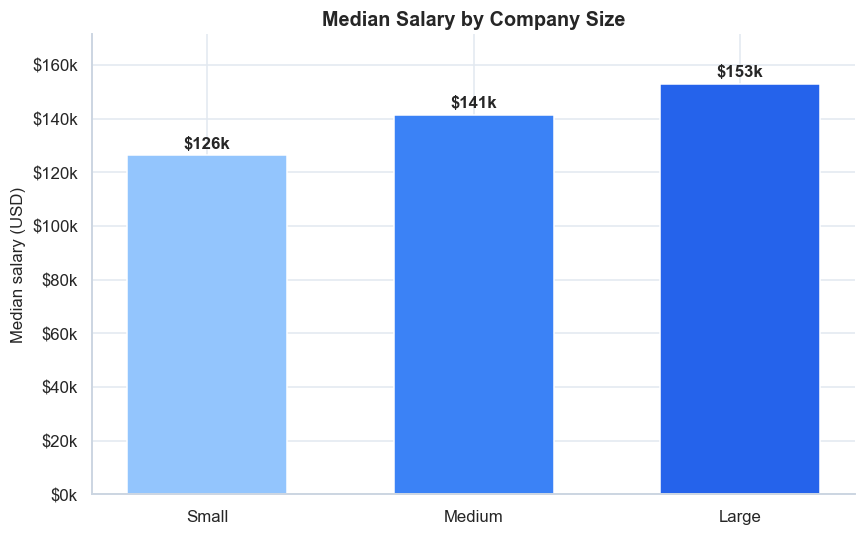

In [24]:
fig, ax = plt.subplots(figsize=(8, 5))
vals = size_stats["median"]
bars = ax.bar(vals.index.astype(str), vals.values,
              color=[BLUE_SEQ[2], BLUE_SEQ[4], PRIMARY], width=0.6)
ax.set_title("Median Salary by Company Size")
ax.set_ylabel("Median salary (USD)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(usd))
for b, v in zip(bars, vals.values):
    ax.text(b.get_x() + b.get_width() / 2, v + max(vals) * 0.01,
            f"${v/1000:.0f}k", ha="center", va="bottom", fontweight="bold")
ax.margins(y=0.12)
sns.despine(fig)
fig.tight_layout()
save_fig(fig, "salary_by_company_size.png")
plt.show()

## 6. Key Findings & Insights

A short, auditable summary of the headline numbers, followed by the insights they
support.

In [25]:
summary = {
    "Roles analysed": f"{len(df):,}",
    "Overall median salary": f"${df['salary_in_usd'].median():,.0f}",
    "Entry-level median": f"${exp_stats.loc['Entry-level', 'median']:,.0f}",
    "Executive median": f"${exp_stats.loc['Executive', 'median']:,.0f}",
    "Exec vs entry multiple": f"{exp_stats.loc['Executive', 'median'] / exp_stats.loc['Entry-level', 'median']:.1f}x",
    "Onsite median": f"${remote_stats.loc['Onsite', 'median']:,.0f}",
    "Remote median": f"${remote_stats.loc['Remote', 'median']:,.0f}",
    "Remote premium": f"{(remote_stats.loc['Remote', 'median'] / remote_stats.loc['Onsite', 'median'] - 1) * 100:.1f}%",
    "Top country (median)": f"{COUNTRY_NAMES.get(country_stats.index[0], country_stats.index[0])} "
                            f"(${country_stats['median_salary'].iloc[0]:,.0f})",
    "Highest-paying role": f"{title_stats['median_salary'].idxmax()} "
                           f"(${title_stats['median_salary'].max():,.0f})",
    "Most in-demand role": f"{title_stats['postings'].idxmax()} "
                           f"({int(title_stats['postings'].max()):,} postings)",
    f"Salary growth {year_stats.index[0]}->{year_stats.index[-1]}": f"{growth:.1f}%",
}
for k, v in summary.items():
    print(f"{k:<32}: {v}")

Roles analysed                  : 8,615
Overall median salary           : $142,000
Entry-level median              : $86,000
Executive median                : $236,050
Exec vs entry multiple          : 2.7x
Onsite median                   : $138,800
Remote median                   : $145,400
Remote premium                  : 4.8%
Top country (median)            : United States ($167,600)
Highest-paying role             : Data Science Manager ($188,500)
Most in-demand role             : Data Engineer (1,579 postings)
Salary growth 2020->2024        : 23.5%


### The six insights

1. **Experience is the dominant pay lever.** Moving from entry-level (~\$86k) to
   executive (~\$236k) multiplies median pay by **~2.7×** — far more than any other
   factor here. For a candidate, *progression beats role-hopping*; for an employer,
   seniority bands must be the backbone of any compensation structure.

2. **Location sets the ceiling.** The United States (~\$168k) and Switzerland
   (~\$162k) pay roughly **3× more** than emerging markets like India (~\$60k) and
   Brazil (~\$55k) for the *same* role. Geography is the second-strongest driver and
   explains much of the spread in the data.

3. **Title shapes both demand and pay — but not equally.** Data Engineer, Data
   Scientist and Data Analyst roles are the most plentiful, yet the top of the pay
   scale belongs to leadership and AI/ML specialist titles (*Data Science Manager*
   ~\$188k, *AI Engineer* ~\$178k). The most common role (Data Analyst, ~\$110k) is
   the **lowest**-paid — volume and value are not the same thing.

4. **The remote premium is real but small.** Fully-remote roles edge out onsite ones
   by only **~5%** (~\$145k vs ~\$139k). Remote flexibility is a lifestyle benefit
   far more than a compensation one — it should not dominate an offer comparison.

5. **Salaries are trending up.** The overall median rose **+23.5%** from 2020 to
   2024 (~\$122k → ~\$151k), at every experience level — a durable tailwind for the
   field and a real cost pressure for employers.

6. **Company size matters least.** Large firms pay modestly more (~\$153k) than small
   ones (~\$126k), but the effect is secondary to experience and location.

## 7. Conclusion

Starting from raw, messy inputs, this case study collected data (including an
ethical scraping demo), cleaned it with documented and defensible decisions,
explored six concrete business questions, and distilled the results into a handful
of clear, decision-ready insights.

**How this creates value for a decision-maker:**

- **For a hiring manager / HR:** the experience, location and company-size effects
  translate directly into **data-driven salary bands** — set competitive offers
  without overpaying or losing candidates to guesswork.
- **For a candidate or career coach:** the analysis shows where the leverage is —
  **seniority and location**, not remote status or chasing the highest-volume
  title — enabling sharper benchmarking and career planning.
- **For a business leader:** the upward salary trend is a **budgeting input** for
  forecasting the rising cost of data talent.

**What I would do next with a real dataset:** swap the synthetic source for the
live Kaggle data (the workflow is unchanged), enrich it with skills/industry
fields, and build a small model to **predict a fair salary** from role, experience
and location — turning this descriptive analysis into a practical pricing tool.

---
*Reproducibility: all data is generated/scraped by the scripts in [`src/`](../src),
the cleaned dataset is saved to `data/processed/`, and every figure is exported to
`assets/`. Re-running the notebook top to bottom reproduces every number and chart
exactly.*